# Wind Resource Analysis

In this notebook, we analyze the behaviour of the wind resource in the area surrounding Vineyard Wind. To do so, wind data (speed at 100 meters) from years 2000-2023 was gathered from the ERA5 dataset. In the following code blocks, we load and treat the data downloaded.

In [53]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr

from collections import defaultdict
from pathlib import Path
from py_wake.site import UniformWeibullSite
from scipy.stats import norm, vonmises, weibull_min
from tqdm import tqdm

sns.set_theme()

In [2]:
wind_data = defaultdict(list)

era5_dir = Path('../../Project_Monte_Carlo/era5_vineyard')

# Vineyard Wind coordinates
vineyard_lat = 40.9508654
vineyard_lon = -70.6705419

for filepath in tqdm(era5_dir.glob("*.grib")):
    # Load data from grib file
    ds = xr.open_dataset(filepath, engine="cfgrib", backend_kwargs={'indexpath': ''})

    # Obtain data relative to Vineyard Wind location
    point = ds.sel(latitude=vineyard_lat, longitude=vineyard_lon, method="nearest")

    # Extract wind speed measurements and timestamp
    wind_data['u'].extend(point["u100"].values)
    wind_data['v'].extend(point["v100"].values)
    wind_data['time'].extend(point.get('valid_time', point.get('time')).values)

# Load data into a pandas dataframe
wind_df = pd.DataFrame(wind_data)


24it [04:52, 12.18s/it]


As we can see from the dataframe excerpt below, the data was acquired every hour during the 24-year period. The measurements relevant to our study consist of the wind speed in the longitudinal ($u$) and latitudinal ($v$) directions.

In [3]:
wind_df.head()

,u,v,time
0,2.193024,-3.932449,2000-01-01 00:00:00
1,3.014343,-3.771240,2000-01-01 01:00:00
2,3.342896,-3.849136,2000-01-01 02:00:00
3,3.421021,-3.781250,2000-01-01 03:00:00
4,3.536407,-3.311142,2000-01-01 04:00:00


We can then extract some additional information from the raw data. First, we get the year the data was acquired. We then obtain the magnitude of the wind speed $w_{s}$, in m/s, and its direction $w_{d}$, in degrees, by applying the equations below.

$$
|w_{s}| = \sqrt{u^{2} + v^{2}}
$$

$$
w_{d} = \frac{180}{\pi} \cdot \arctan{\left( \frac{u}{v} \right)}
$$

Finally, based on the wind direction, we classify the measurements into one of the 12 sectors defined, each one encompassing 30°.

In [4]:
wind_df['year'] = wind_df.time.apply(lambda s: s.year)
wind_df['speed'] = np.sqrt(wind_df.u ** 2 + wind_df.v ** 2)
wind_df['direction'] = np.rad2deg(np.arctan2(wind_df.u, wind_df.v))
wind_df['sector'] = (180 + wind_df.direction) // 30

Below we can see the final dataframe with its new columns.

In [5]:
wind_df.head()

,u,v,time,year,speed,direction,sector
0,2.193024,-3.932449,2000-01-01 00:00:00,2000,4.502612,150.852737,11.0
1,3.014343,-3.771240,2000-01-01 01:00:00,2000,4.827889,141.364731,10.0
2,3.342896,-3.849136,2000-01-01 02:00:00,2000,5.098117,139.026352,10.0
3,3.421021,-3.781250,2000-01-01 03:00:00,2000,5.099140,137.863312,10.0
4,3.536407,-3.311142,2000-01-01 04:00:00,2000,4.844568,133.115799,10.0


## Exploring wind data

With the data now treated, we can start exploring it to better understand it. First, let's see how the wind speed and direction are distributed on our dataset.


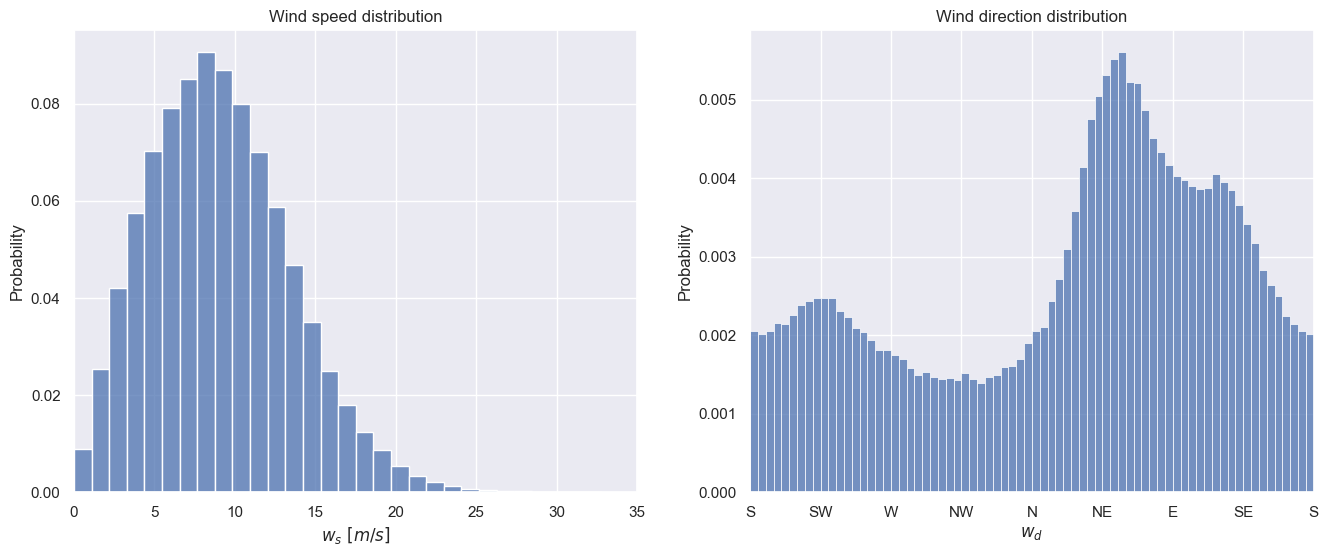

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(wind_df, x='speed', bins=30, ax=ax1, stat="density")
ax1.set_title('Wind speed distribution')
ax1.set_xlabel(r'$w_{s} \ [m/s]$')
ax1.set_ylabel('Probability')
ax1.set_xlim(0, 35)

sns.histplot(wind_df, x='direction', bins=72, ax=ax2, stat="density")
ax2.set_title('Wind direction distribution')
ax2.set_xlabel(r'$w_{d}$')
ax2.set_ylabel('Probability')
ax2.set_xlim(-180, 180)
ax2.set_xticks([-180, -135, -90, -45, 0, 45, 90, 135, 180])
ax2.set_xticklabels(['S', 'SW', 'W', 'NW', 'N', 'NE', 'E', 'SE', 'S'])

plt.show()

We can see from the graphs above there is a predominance of wind speed around 8 m/s and that it slowly decays until reaching 25 m/s. On the wind direction, the majority of the wind blows towards Northeast (NE), with peaks towards Southeast (SE) and Southwest (SW) directions.

Let's now break down the wind speed distribution to each of the 30-degree sectors to see how they differ.


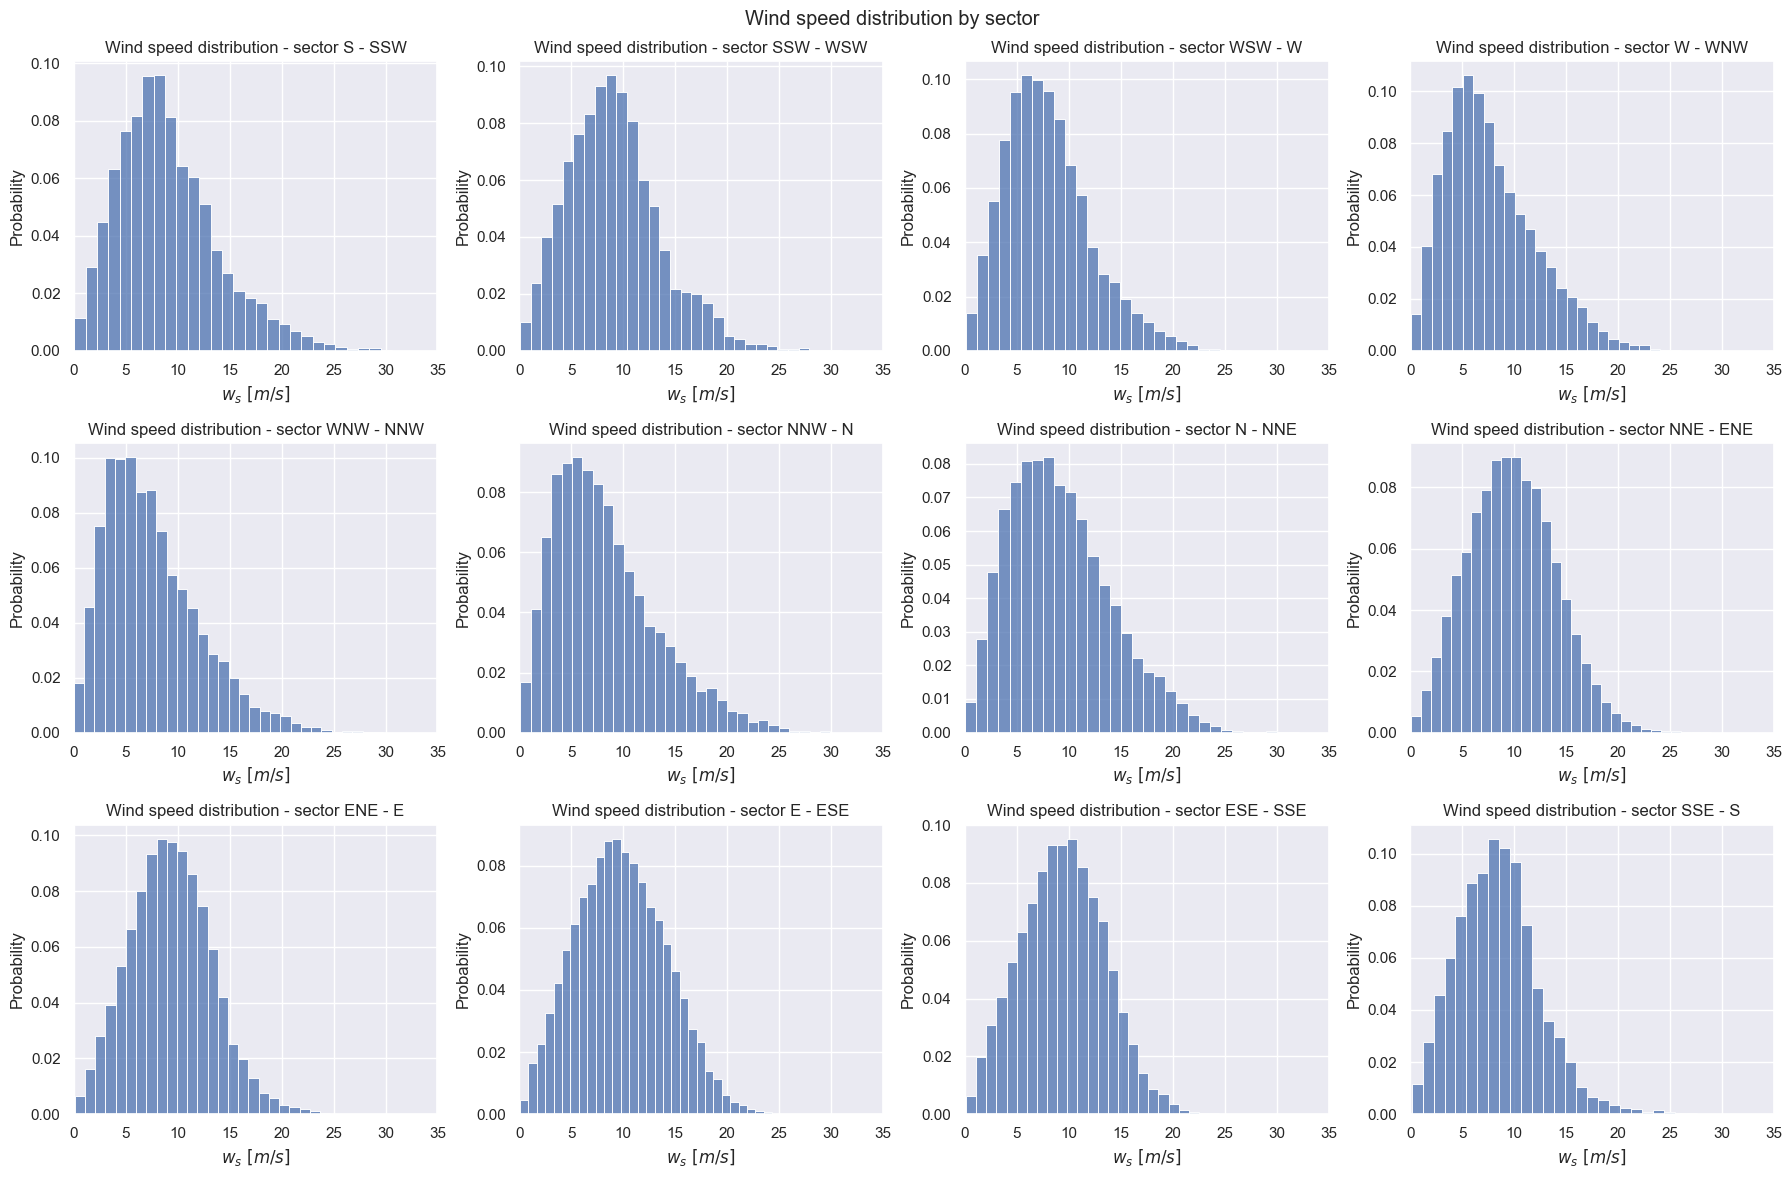

In [7]:
fig, axs = plt.subplots(3, 4, figsize=(18, 12))

sector_labels = {
    0: 'S - SSW', 1: 'SSW - WSW', 2: 'WSW - W',
    3: 'W - WNW', 4: 'WNW - NNW', 5: 'NNW - N',
    6: 'N - NNE', 7: 'NNE - ENE', 8: 'ENE - E',
    9: 'E - ESE', 10: 'ESE - SSE', 11: 'SSE - S',
}

for (ax, sector) in zip(axs.reshape(-1), sorted(wind_df.sector.unique())):
    sns.histplot(wind_df[wind_df.sector == sector], x='speed', bins=30, ax=ax, stat="density")
    ax.set_title(f'Wind speed distribution - sector {sector_labels[sector]}')
    ax.set_xlabel(r'$w_{s} \ [m/s]$')
    ax.set_ylabel('Probability')
    ax.set_xlim(0, 35)

fig.suptitle('Wind speed distribution by sector')
fig.tight_layout()
plt.show()

From the graphs, we can observe that higher wind speeds occur more often in the prevailing directions (sectors NNE-ENE, ENE-E, E-ESE, and ESE-SSE). This is indicated by the peak curve happening at higher values of $w_{s}$.

Likewise, we can analyse how the wind direction changes across the 24 years of data.

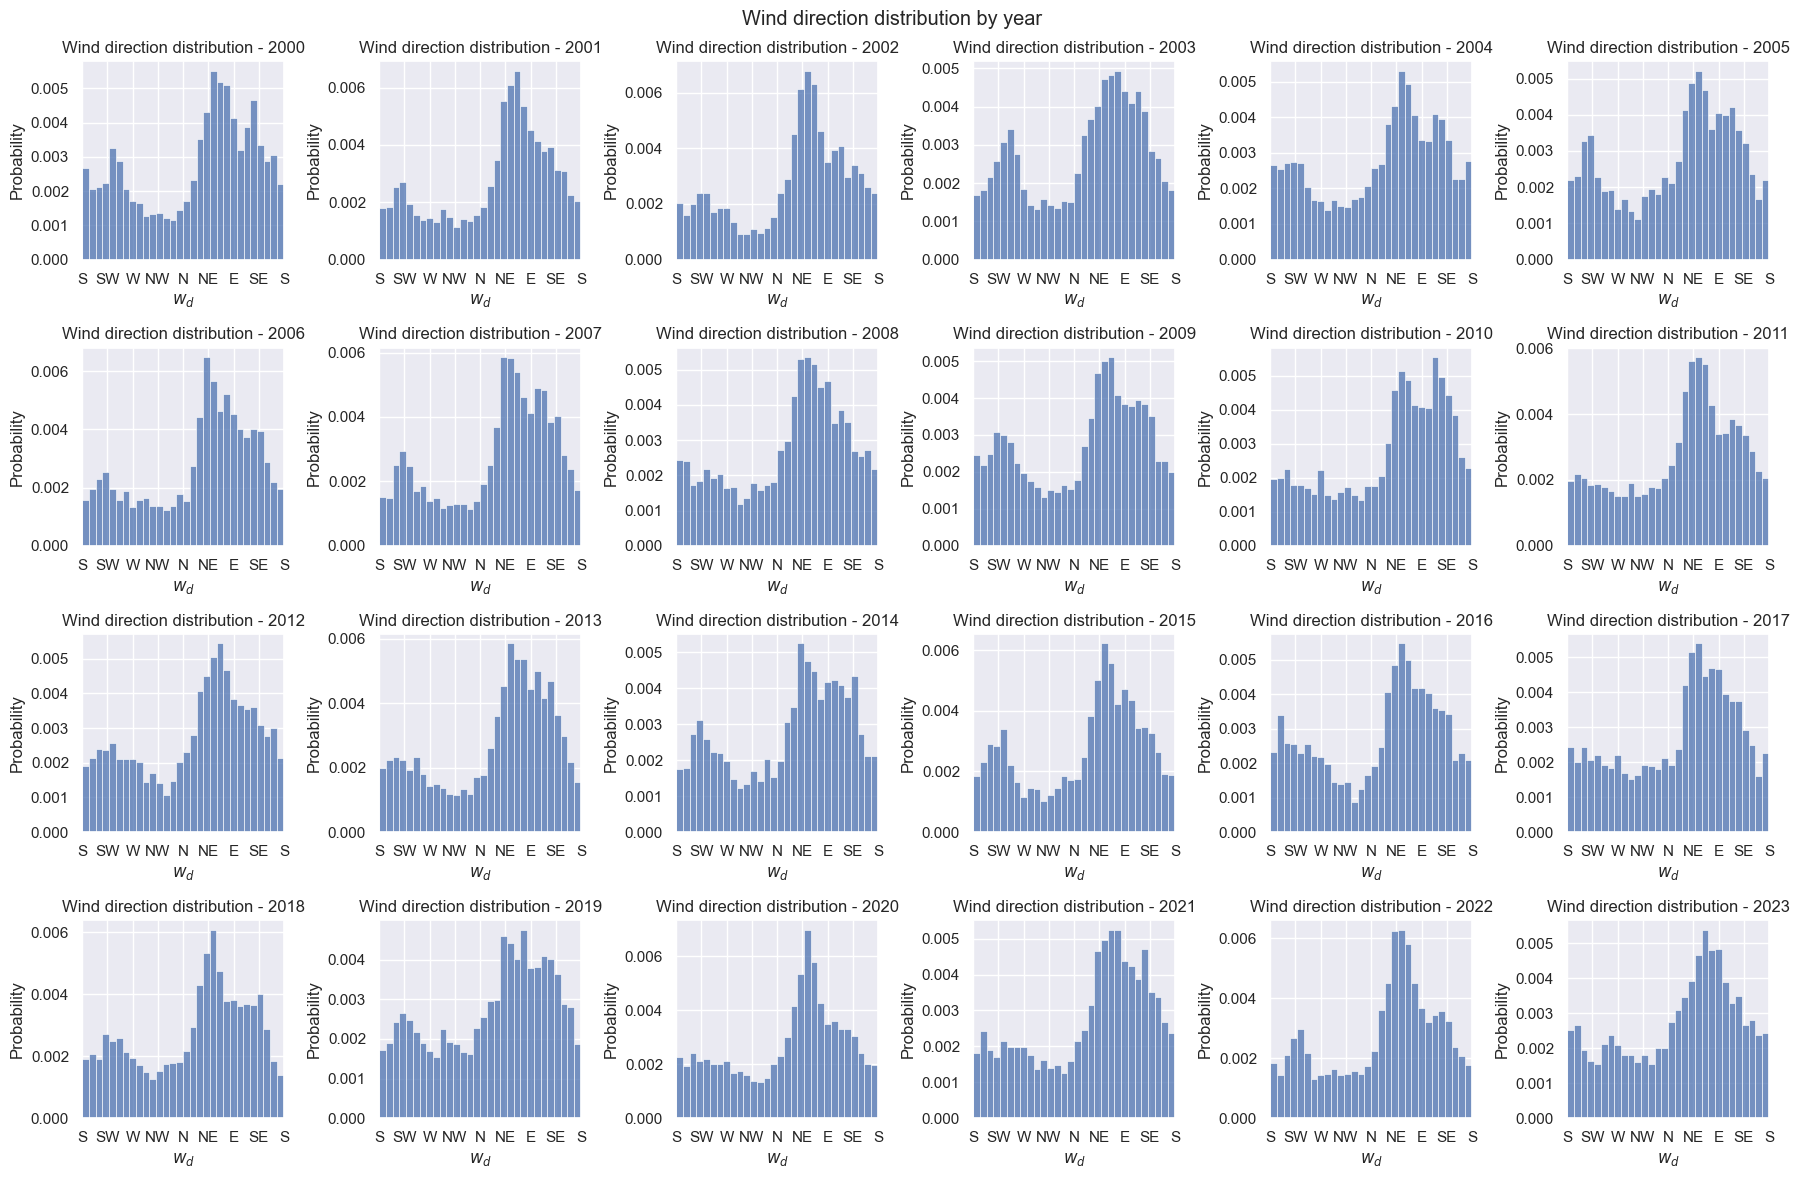

In [8]:
fig, axs = plt.subplots(4, 6, figsize=(18, 12))

for (ax, year) in zip(axs.reshape(-1), sorted(wind_df.year.unique())):
    sns.histplot(wind_df[wind_df.year == year], x='direction', bins=30, ax=ax, stat="density")
    ax.set_title(f'Wind direction distribution - {year}')
    ax.set_xlabel(r'$w_{d}$')
    ax.set_ylabel('Probability')
    ax.set_xlim(-180, 180)
    ax.set_xticks([-180, -135, -90, -45, 0, 45, 90, 135, 180])
    ax.set_xticklabels(['S', 'SW', 'W', 'NW', 'N', 'NE', 'E', 'SE', 'S'])

fig.suptitle('Wind direction distribution by year')
fig.tight_layout()
plt.show()

We can see from the plots above how the direction of the wind is not constant through the time period chosen for the analysis. However, we can observe a trend in the distributions, with higher concentrations around the East-northeast (ENE) direction. There is also a small concentration centered in the Southwest (SW) direction.

## Wind speed distribution

It is common in the literature to fit the wind speed $w_{s}$ into a Weibull distribution. Its probability density function (PDF) is given by the following equation, where $\kappa \in \mathbb{R}^{+}$ is the shape parameter and $\lambda \in \mathbb{R}^{+}$ is the scale parameter.

$$
f(x, \lambda, \kappa) = \begin{cases} \frac{\kappa}{\lambda} \left( \frac{x}{\lambda} \right)^{\kappa - 1} e^{-(x/\lambda)^{\kappa}} &, \ x \geq 0 \\ 0 &, \ x \lt 0 \end{cases}
$$

By altering the values of parameters $\kappa$ and $\lambda$, we can adjust the PDF curve to fit it to the observed data, as shown below.

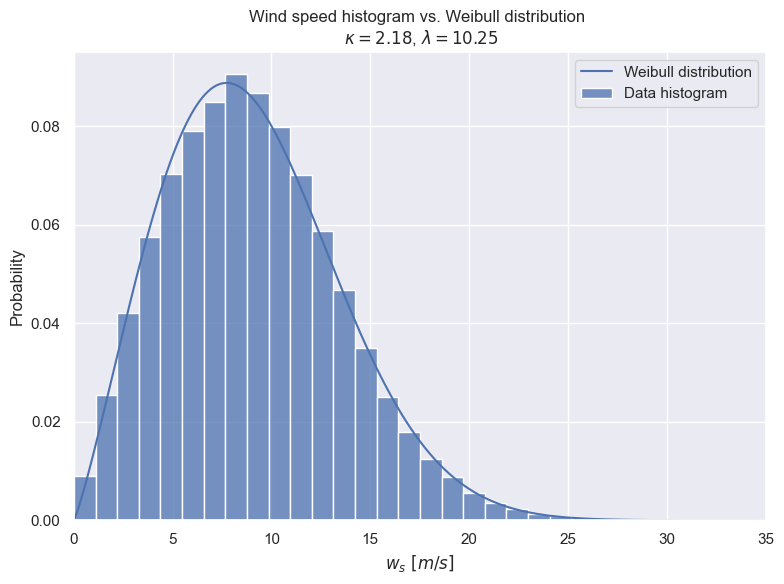

In [9]:
# Fit weibull to wind speed data
kappa, _, lambda_ = weibull_min.fit(wind_df.speed, floc=0)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.histplot(wind_df, x='speed', bins=30, ax=ax, stat="density", label='Data histogram')
sns.lineplot(x=np.linspace(0, 35, 1000), y=weibull_min.pdf(np.linspace(0, 35, 1000), c=kappa, scale=lambda_), ax=ax, label="Weibull distribution")
ax.set_title(f'Wind speed histogram vs. Weibull distribution \n $\\kappa = {kappa:.2f}$, $\\lambda = {lambda_:.2f}$')
ax.set_xlabel(r'$w_{s} \ [m/s]$')
ax.set_ylabel('Probability')
ax.set_xlim(0, 35)
ax.legend()

plt.tight_layout()
plt.show()

The parameter values for the curve above were obtained via Maximum Likelihood Estimation (MLE). This parameter estimation method works by tweaking the parameters of the distribution towards the direction that maximizes the likelihood of the data being originated from a giving statistical distribution.

We can also apply this concept to model the wind speed distribution for each of the sectors, like shown before.

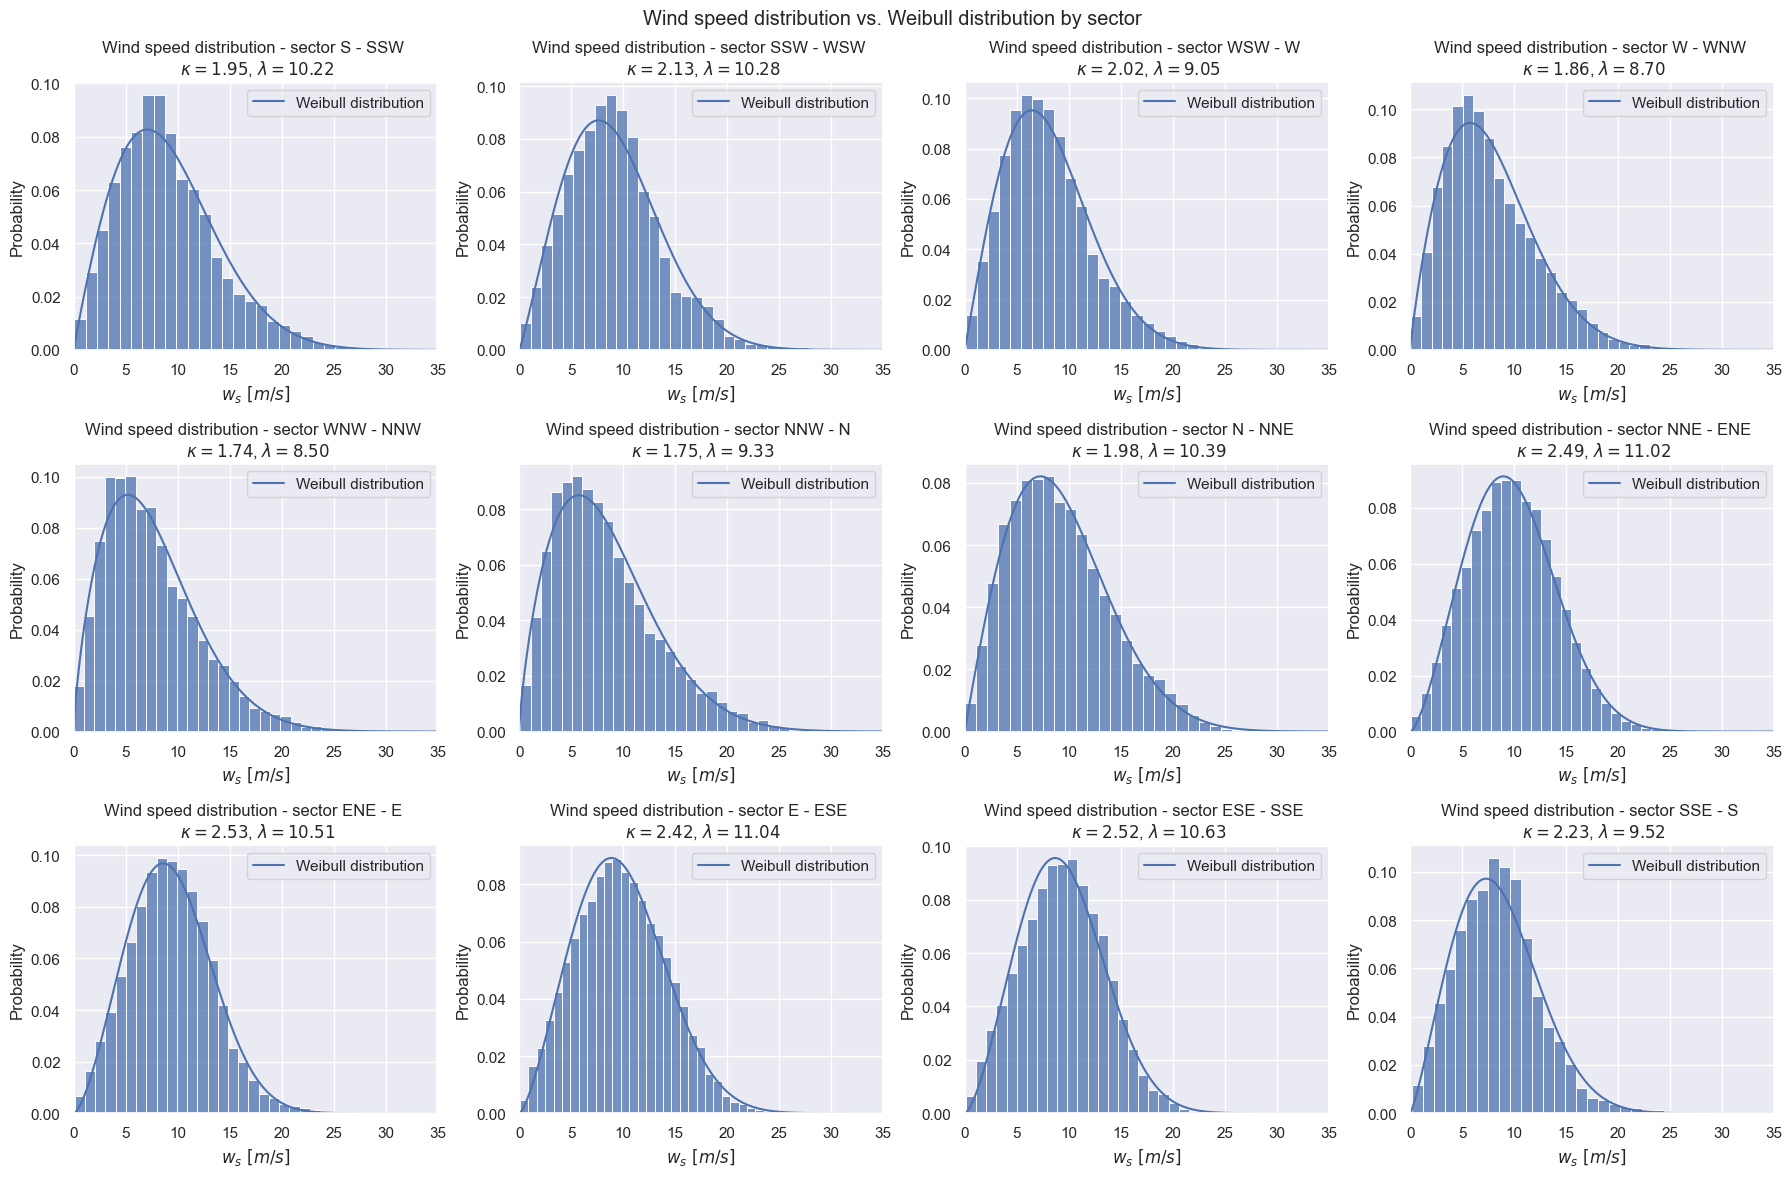

In [10]:
fig, axs = plt.subplots(3, 4, figsize=(18, 12))

for (ax, sector) in zip(axs.reshape(-1), sorted(wind_df.sector.unique())):
    sns.histplot(wind_df[wind_df.sector == sector], x='speed', bins=30, ax=ax, stat="density")

    kappa, _, lambda_ = weibull_min.fit(wind_df[wind_df.sector == sector].speed, floc=0)
    sns.lineplot(x=np.linspace(0, 35, 1000), y=weibull_min.pdf(np.linspace(0, 35, 1000), c=kappa, scale=lambda_), ax=ax, label="Weibull distribution")

    ax.set_title(f'Wind speed distribution - sector {sector_labels[sector]} \n $\\kappa = {kappa:.2f}$, $\\lambda = {lambda_:.2f}$')

    ax.set_xlabel(r'$w_{s} \ [m/s]$')
    ax.set_ylabel('Probability')
    ax.set_xlim(0, 35)
    ax.legend()

fig.suptitle('Wind speed distribution vs. Weibull distribution by sector')
fig.tight_layout()
plt.show()

We can see from above that each of the curves will have different values for the shape and scale parameters. This behaviour was expected, since the wind regime varies for each sector.

## Wind direction distribution

Wind direction, on the other hand, are usually modelled as following a von Mises distribution or, more likely, a combination of them. the von Mises distribution can be interpreted as a normal distribution for circular data such as wind direction. The PDF for this type of distribution is defined by the equation below, where $\mu \in \mathbb{R}$ and $\kappa \in \mathbb{R}^{+}$ are the location and concentration parameters, respectively. Their effects on the von Mises distribution are analogous to the mean and variance on the normal distribution. Finally, $I_{0}(\kappa)$ is the modified Bessel function of the first kind of order 0.

$$
f(x, \mu, \kappa) = \frac{e^{\kappa \cos(x - \mu)}}{2 \pi I_{0}(\kappa)}
$$

Below, we try and fit a single von Mises distribution to our wind direction data.

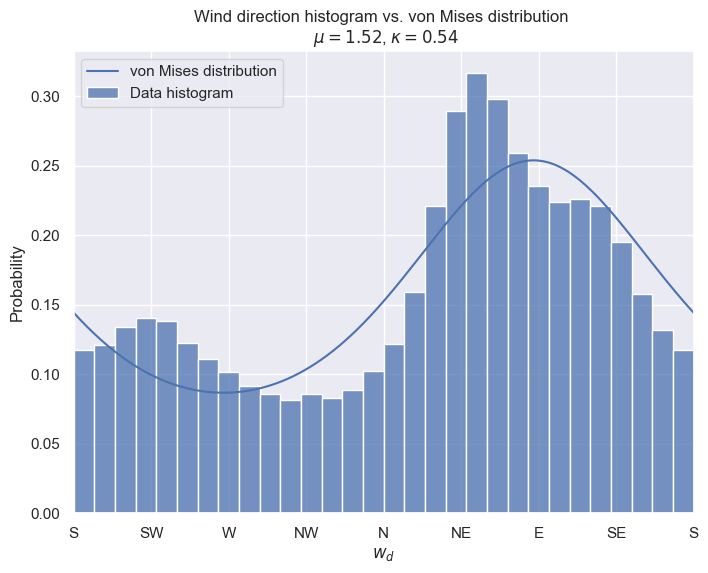

In [11]:
kappa_, mu, _ = vonmises.fit(np.deg2rad(wind_df.direction))

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.histplot(wind_df, x=wind_df.direction.apply(np.deg2rad), bins=30, ax=ax, stat="density", label='Data histogram')
sns.lineplot(x=np.linspace(-np.pi, np.pi, 1000), y=vonmises.pdf(np.linspace(-np.pi, np.pi, 1000), loc=mu, kappa=kappa_), ax=ax, label="von Mises distribution")
ax.set_title(f'Wind direction histogram vs. von Mises distribution \n $\\mu = {mu:.2f}$, $\\kappa = {kappa_:.2f}$')
ax.set_xlabel(r'$w_{d}$')
ax.set_ylabel('Probability')
ax.set_xlim(-np.pi, np.pi)
ax.set_xticks(np.linspace(-np.pi, np.pi, 9))
ax.set_xticklabels(['S', 'SW', 'W', 'NW', 'N', 'NE', 'E', 'SE', 'S'])

ax.legend()
plt.show()

We can see from the graph above that, although being able to somewhat capture the major trend of our data, a single von Mises distribution cannot provide a detailed representation of the wind direction. In order to improve the match of the distribution to the data, we can instead use multiple distributions. The final PDF for an approach that uses $K$ von Mises distributions is given by the equation below, where $w_{k}$ is the weight given to the k-th distribution with parameter $\mu_{k}$ and $\kappa_{k}$, i.e. how much that mode influences the overall behaviour. Note that $\sum\limits^{K} w_{k} = 1$.

$$
f(x, \mu, \kappa) = \sum_{k=1}^{K} w_{k} \frac{e^{\kappa_{k} \cos(x - \mu_{k})}}{2 \pi I_{0}(\kappa_{k})}
$$

The following code block defines a function able to fit multimodal von Mises distributions to a given circular data.

In [12]:
def fit_multimodal_von_mises(data, n=2, max_iter=1000, tol=1e-4):
    """Fit N von Mises distributions to data"""
    mus = np.linspace(-np.pi+1e3, np.pi, n, endpoint=False)
    kappas = 2 * np.ones(n)
    weights = np.ones(n) / n

    n_samples = data.shape[0]

    log_likelihood_old = -np.inf

    for iteration in range(max_iter):
        # --- E-Step: Compute responsibilities ---

        pdfs = np.zeros((n_samples, n))
        for j in range(n):
            pdfs[:, j] = vonmises.pdf(data, kappas[j], loc=mus[j])

        weighted_pdfs = pdfs * weights
        sum_weighted_pdfs = np.sum(weighted_pdfs, axis=1, keepdims=True)

        # Avoid division by zero
        responsibilities = weighted_pdfs / (sum_weighted_pdfs + 1e-15)

        # --- M-Step: Update parameters ---
        resp_sum = np.sum(responsibilities, axis=0)
        weights = resp_sum / n_samples

        for j in range(n):
            # Weighted directional center components
            cos_sum = np.sum(responsibilities[:, j] * np.cos(data))
            sin_sum = np.sum(responsibilities[:, j] * np.sin(data))

            # Update Mean direction
            mus[j] = np.arctan2(sin_sum, cos_sum)

            # Update Concentration (kappa)
            r_bar = np.sqrt(cos_sum**2 + sin_sum**2) / (resp_sum[j] + 1e-15)
            r_bar = np.clip(r_bar, 1e-4, 0.999)  # Avoid numerical limits

            if r_bar < 0.53:
                kappas[j] = 2 * r_bar + r_bar**3 + (5 * r_bar**5) / 6
            elif r_bar < 0.85:
                kappas[j] = -0.4 + 1.39 * r_bar + 0.43 / (1 - r_bar)
            else:
                kappas[j] = 1 / (r_bar**3 - 4 * r_bar**2 + 3 * r_bar)

            kappas[j] = np.clip(kappas[j], 0.1, 50.0)

        # Check convergence via Log-Likelihood
        log_likelihood = np.sum(np.log(np.sum(weighted_pdfs, axis=1) + 1e-15))
        if np.abs(log_likelihood - log_likelihood_old) < tol:
            break

        log_likelihood_old = log_likelihood

    return weights, mus, kappas, log_likelihood_old

With the function implemented, we can see how increasing the number of modes of our distribution affects the fitting to the wind direction measurements. Below, we fit distribution ranging from 2 to 9 modes.

In [13]:
# Calculate distributions parameters for various multimodal distributions
multimodal_von_mises = {n: fit_multimodal_von_mises(np.deg2rad(wind_df.direction), n=n, max_iter=200) for n in range(2, 10)}

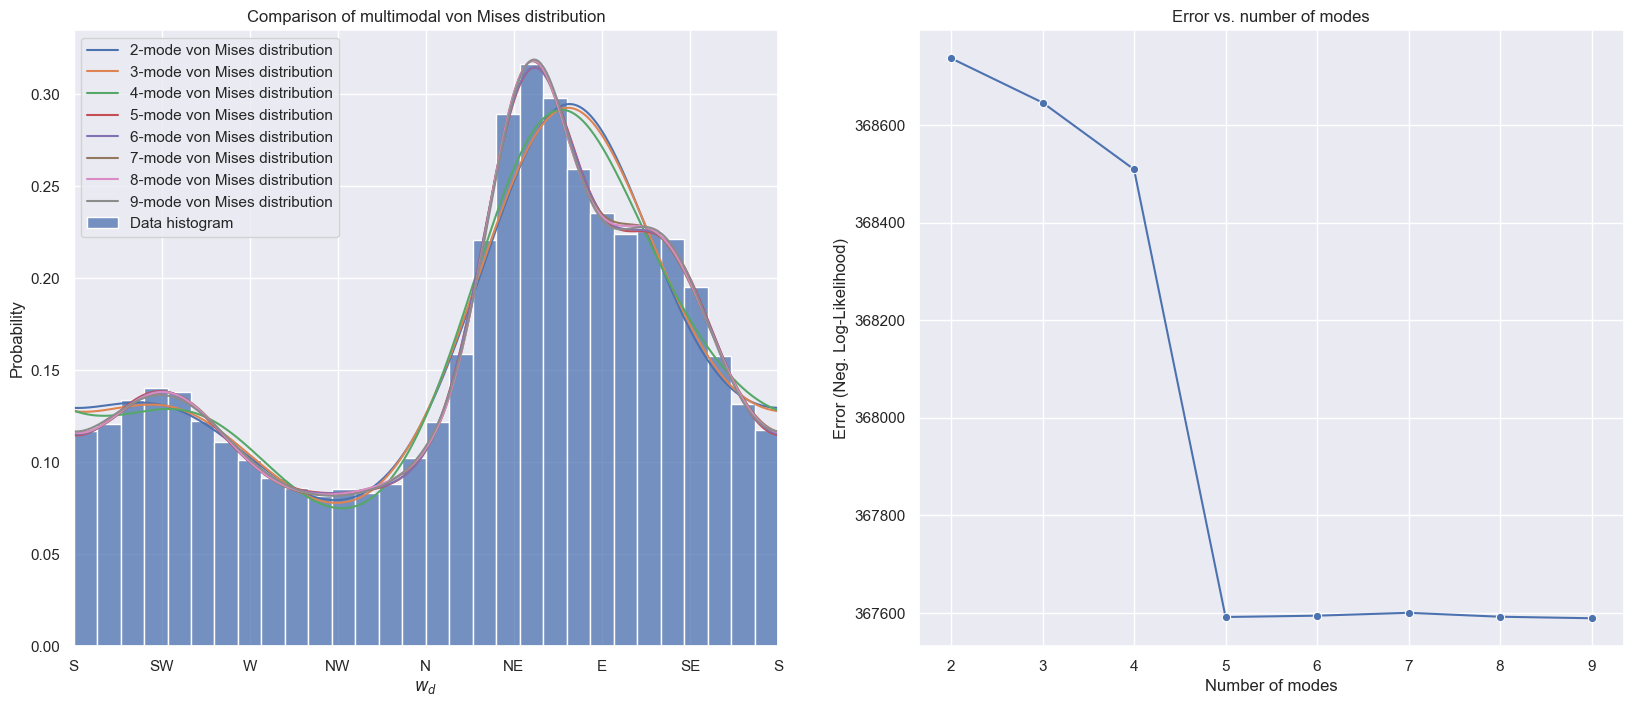

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.histplot(wind_df, x=wind_df.direction.apply(np.deg2rad), bins=30, ax=ax1, stat="density", label='Data histogram')

x_plot = np.linspace(-np.pi, np.pi, 1000)
for n, (weights, mus, kappas, error) in multimodal_von_mises.items():
    sns.lineplot(x=x_plot, y=np.sum([w * vonmises.pdf(x_plot, loc=mu, kappa=kappa) for w, mu, kappa in zip(weights, mus, kappas)], axis=0), ax=ax1, label=f'{n}-mode von Mises distribution')

sns.lineplot(x=multimodal_von_mises.keys(), y=[-error for _, _, _,  error in multimodal_von_mises.values()], ax=ax2, marker='o')

ax1.set_title(f'Comparison of multimodal von Mises distribution')
ax1.set_xlabel(r'$w_{d}$')
ax1.set_ylabel('Probability')
ax1.set_xlim(-np.pi, np.pi)
ax1.set_xticks(np.linspace(-np.pi, np.pi, 9))
ax1.set_xticklabels(['S', 'SW', 'W', 'NW', 'N', 'NE', 'E', 'SE', 'S'])

ax2.set_title(f'Error vs. number of modes')
ax2.set_xlabel('Number of modes')
ax2.set_ylabel('Error (Neg. Log-Likelihood)')

plt.show()

By plotting the PDFs of the previously obtained multimodal von Mises distributions, we can see how their shapes approximate to the histogram as we increase the number of modes. More notably, we can see that distributions with 2, 3, and 4 modes struggle to match the complete behaviour present in the data. Distributions with five or more modes, on the other hand, are able to better approximate the probabilities observed in the data.

This is also noticeable on the graph displaying the error according to the number of modes. From there we can conclude that the optimum number of modes to model the wind direction on this site is 5.

In [15]:
von_mises_per_year = {int(year): fit_multimodal_von_mises(np.deg2rad(wind_df[wind_df.year == year].direction), n=5, max_iter=1000) for year in wind_df.year.unique()}

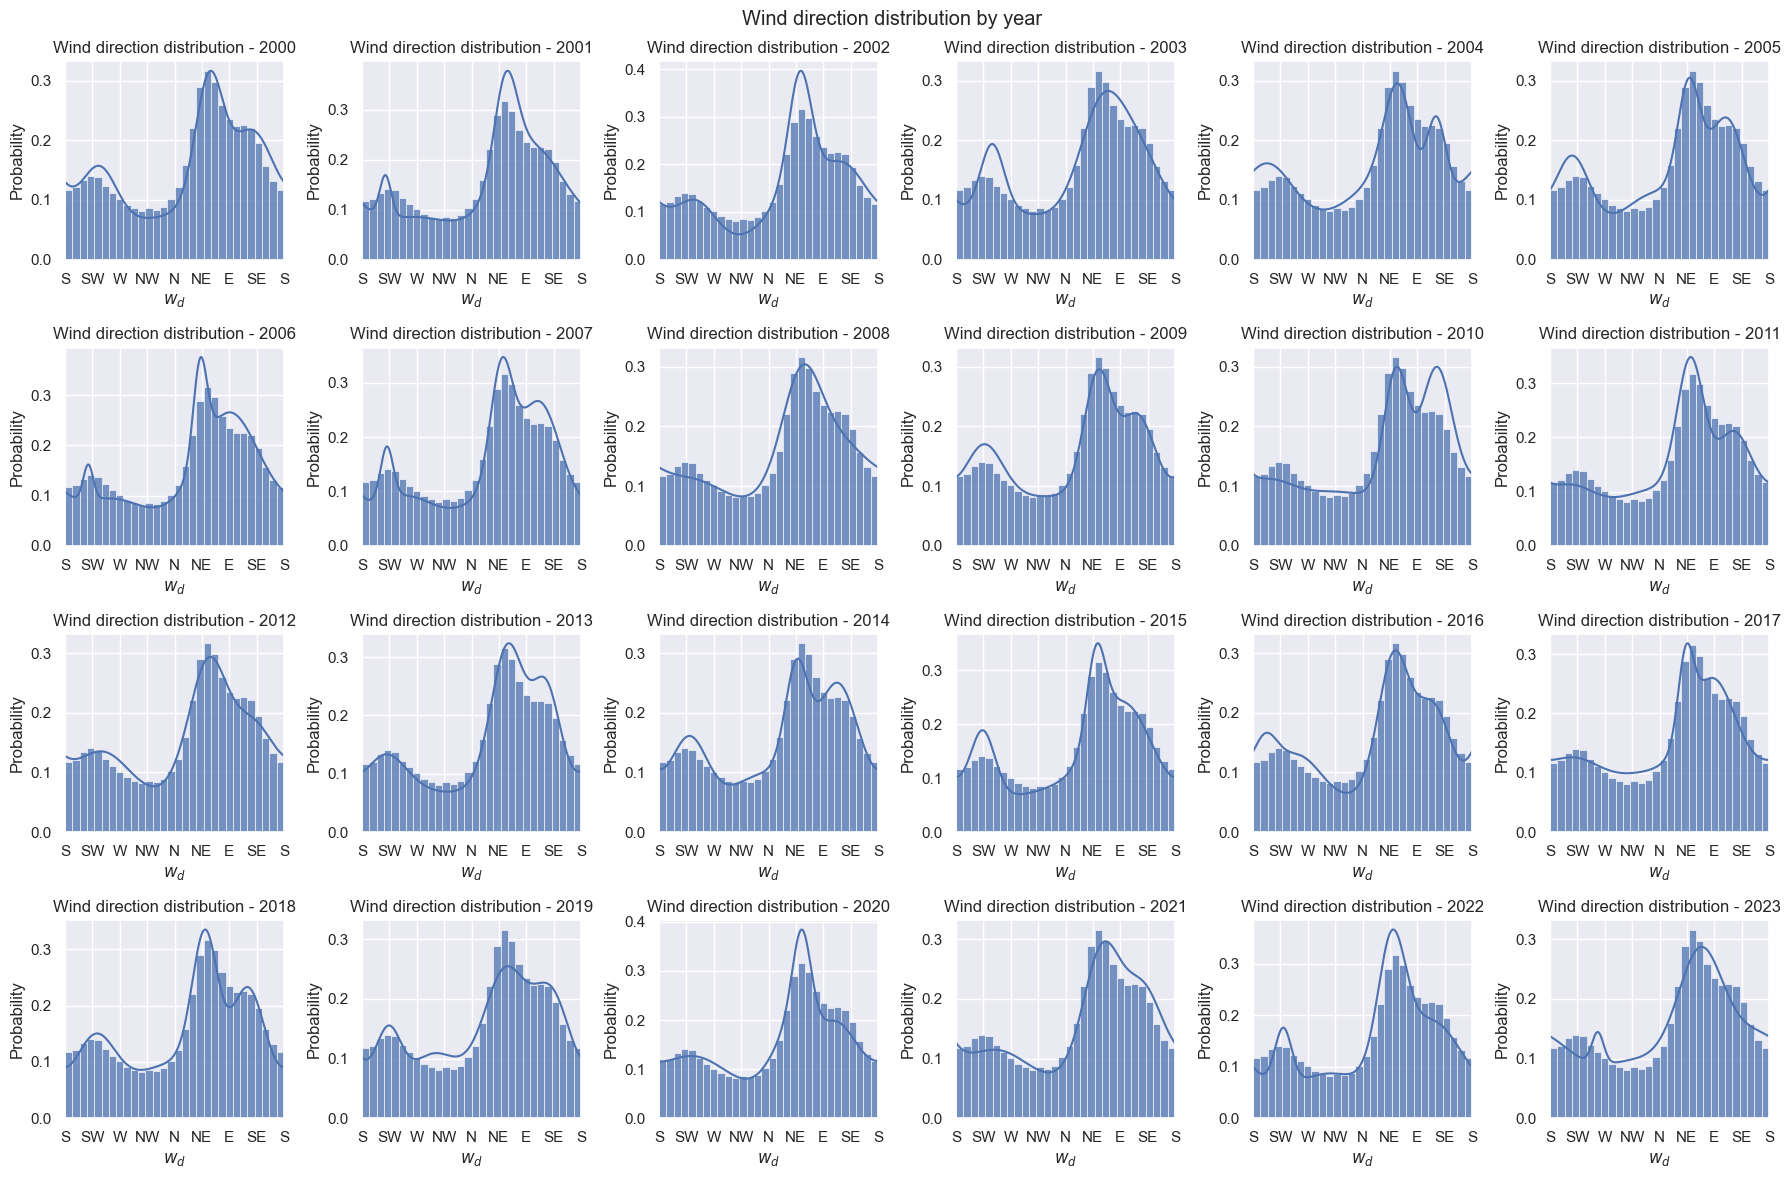

In [16]:
fig, axs = plt.subplots(4, 6, figsize=(18, 12))

for (ax, year) in zip(axs.reshape(-1), sorted(wind_df.year.unique())):
    sns.histplot(wind_df, x=wind_df.direction.apply(np.deg2rad), bins=30, ax=ax, stat="density")
    wind_df.direction.apply(np.deg2rad)
    weights, mus, kappas, _ = von_mises_per_year[year]
    sns.lineplot(x=x_plot, y=np.sum([w * vonmises.pdf(x_plot, loc=mu, kappa=kappa) for w, mu, kappa in zip(weights, mus, kappas)], axis=0), ax=ax)

    ax.set_title(f'Wind direction distribution - {year}')
    ax.set_xlabel(r'$w_{d}$')
    ax.set_ylabel('Probability')
    ax.set_xlim(-np.pi, np.pi)
    ax.set_xticks(np.linspace(-np.pi, np.pi, 9))
    ax.set_xticklabels(['S', 'SW', 'W', 'NW', 'N', 'NE', 'E', 'SE', 'S'])

fig.suptitle('Wind direction distribution by year')
fig.tight_layout()
plt.show()

# Modeling uncertainties of wind resource

As shown on the previous sections, we can model wind speed and direction on a given site using Weibull and multimodal von Mises distributions, respectively. Such distributions are defined by a set of parameters and, in the case of a multimodal distribution, weights. We can then model uncertainties on the wind resource by considering uncertainties in these parameters.

Every time we sample the data and fit the distributions to the wind speed and direction, we will obtain a different value for the Weibull and von Mises parameters. If we sample enough times (usually at least 30 times), we will observe that parameters will be distributed following to a Gaussian curve. This is due to asymptotic normality of Maximum Likelihood Estimators (read more [here](https://gregorygundersen.com/blog/2019/11/28/asymptotic-normality-mle/) and [here](https://stephens999.github.io/fiveMinuteStats/asymptotic_normality_mle.html)). Because of that, a parameter estimation $\hat{\theta}$ obtained via MLE is distributed according to

$$
\hat{\theta} \sim \mathcal{N}(\theta^{*}, \mathcal{I}_{N}(\theta^{*})^{-1})
$$

, where $\theta^{*}$ is the real value of the parameter, and $\mathcal{I}_{N}$ is the Fisher information.

Therefore, if we estimate the parameters many times, we can obtain curves that describe their distribution. From that, we can sample new values to generate possible wind conditions (speed and direction).

In the next code block, we sample the dataset 50 times and estimate the parameters:
 - $\kappa$ and $\lambda$ for 12 Weibull distributions (one for each 30° sector) that models the wind speed; and
 - $w_k$, $\mu_k$, and $\kappa_k$ for the 5-mode von Mises distribution that models the wind direction.

In [17]:
wb_kappa = np.array([])
wb_lambda = np.array([])

vm_weights = np.array([])
vm_mus = np.array([])
vm_kappas = np.array([])

for _ in range(50):
    sample = wind_df.sample(n=24 * 365)

    for sector in sorted(wind_df.sector.unique()):
        k, _, l = weibull_min.fit(sample[sample.sector == sector].speed, floc=0)
        wb_kappa = np.append(wb_kappa, k)
        wb_lambda = np.append(wb_lambda, l)

    w, mu, k, _ = fit_multimodal_von_mises(np.deg2rad(sample.direction), n=5, max_iter=1000)
    vm_weights = np.append(vm_weights, w)
    vm_mus = np.append(vm_mus, mu)
    vm_kappas = np.append(vm_kappas, k)

wb_kappa.shape = (-1, 12)
wb_lambda.shape = (-1, 12)

vm_weights.shape = (-1, 5)
vm_mus.shape = (-1, 5)
vm_kappas.shape = (-1, 5)

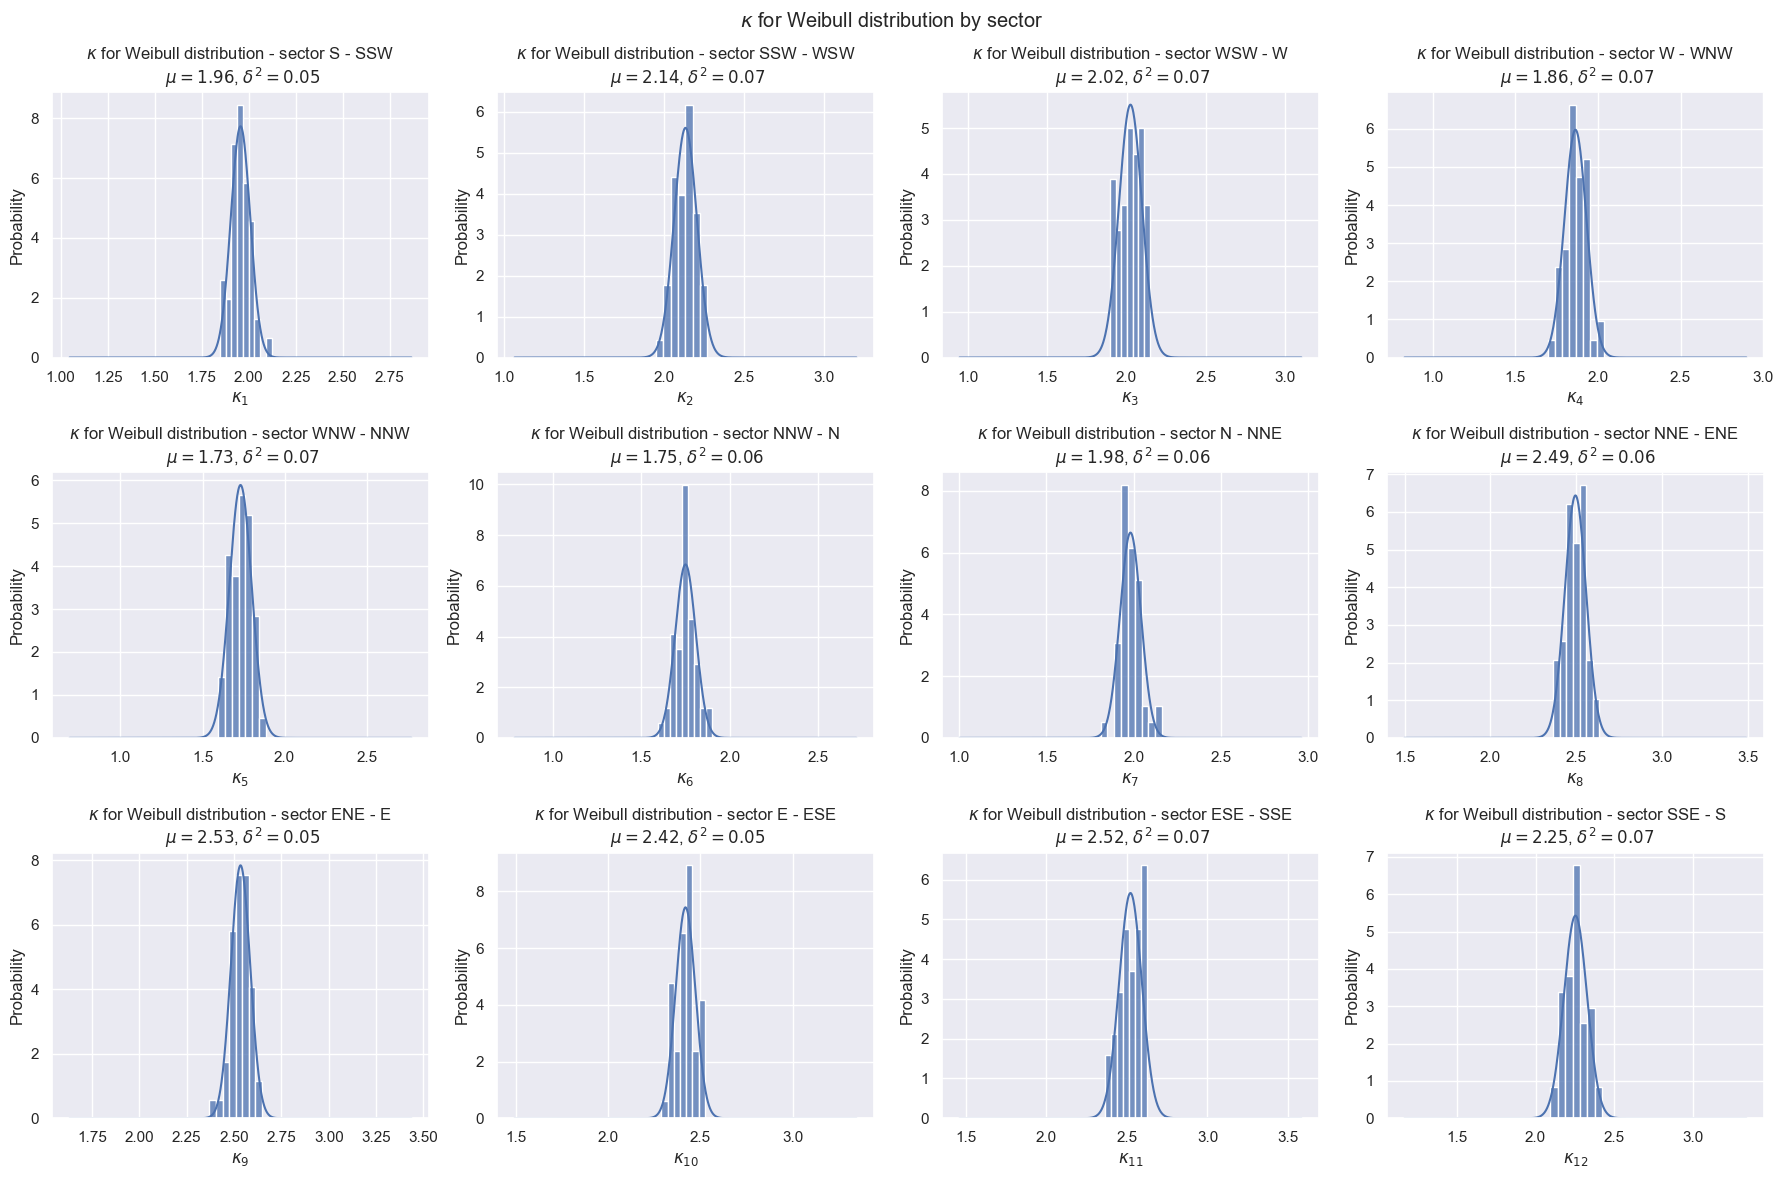

In [79]:
wb_kappa_distros = []
fig, axs = plt.subplots(3, 4, figsize=(18, 12))

for (ax, sector) in zip(axs.reshape(-1), sorted(wind_df.sector.unique())):
    sns.histplot(wb_kappa[:, int(sector)], ax=ax, stat="density")

    mean, var = norm.fit(wb_kappa[:, int(sector)])
    wb_kappa_distros.append(norm(loc=mean, scale=var))
    x_plot = np.linspace(mean - 4 * np.sqrt(var), mean + 4 * np.sqrt(var), 1000)
    sns.lineplot(x=x_plot, y=norm.pdf(x_plot, loc=mean, scale=var), ax=ax)

    ax.set_title(f'$\\kappa$ for Weibull distribution - sector {sector_labels[sector]} \n $\\mu={mean:.2f}$, $\\delta^2 = {var:.2f}$')
    ax.set_xlabel(rf'$\kappa_{{{int(sector) + 1}}}$')
    ax.set_ylabel('Probability')

fig.suptitle(rf'$\kappa$ for Weibull distribution by sector')
fig.tight_layout()
plt.show()

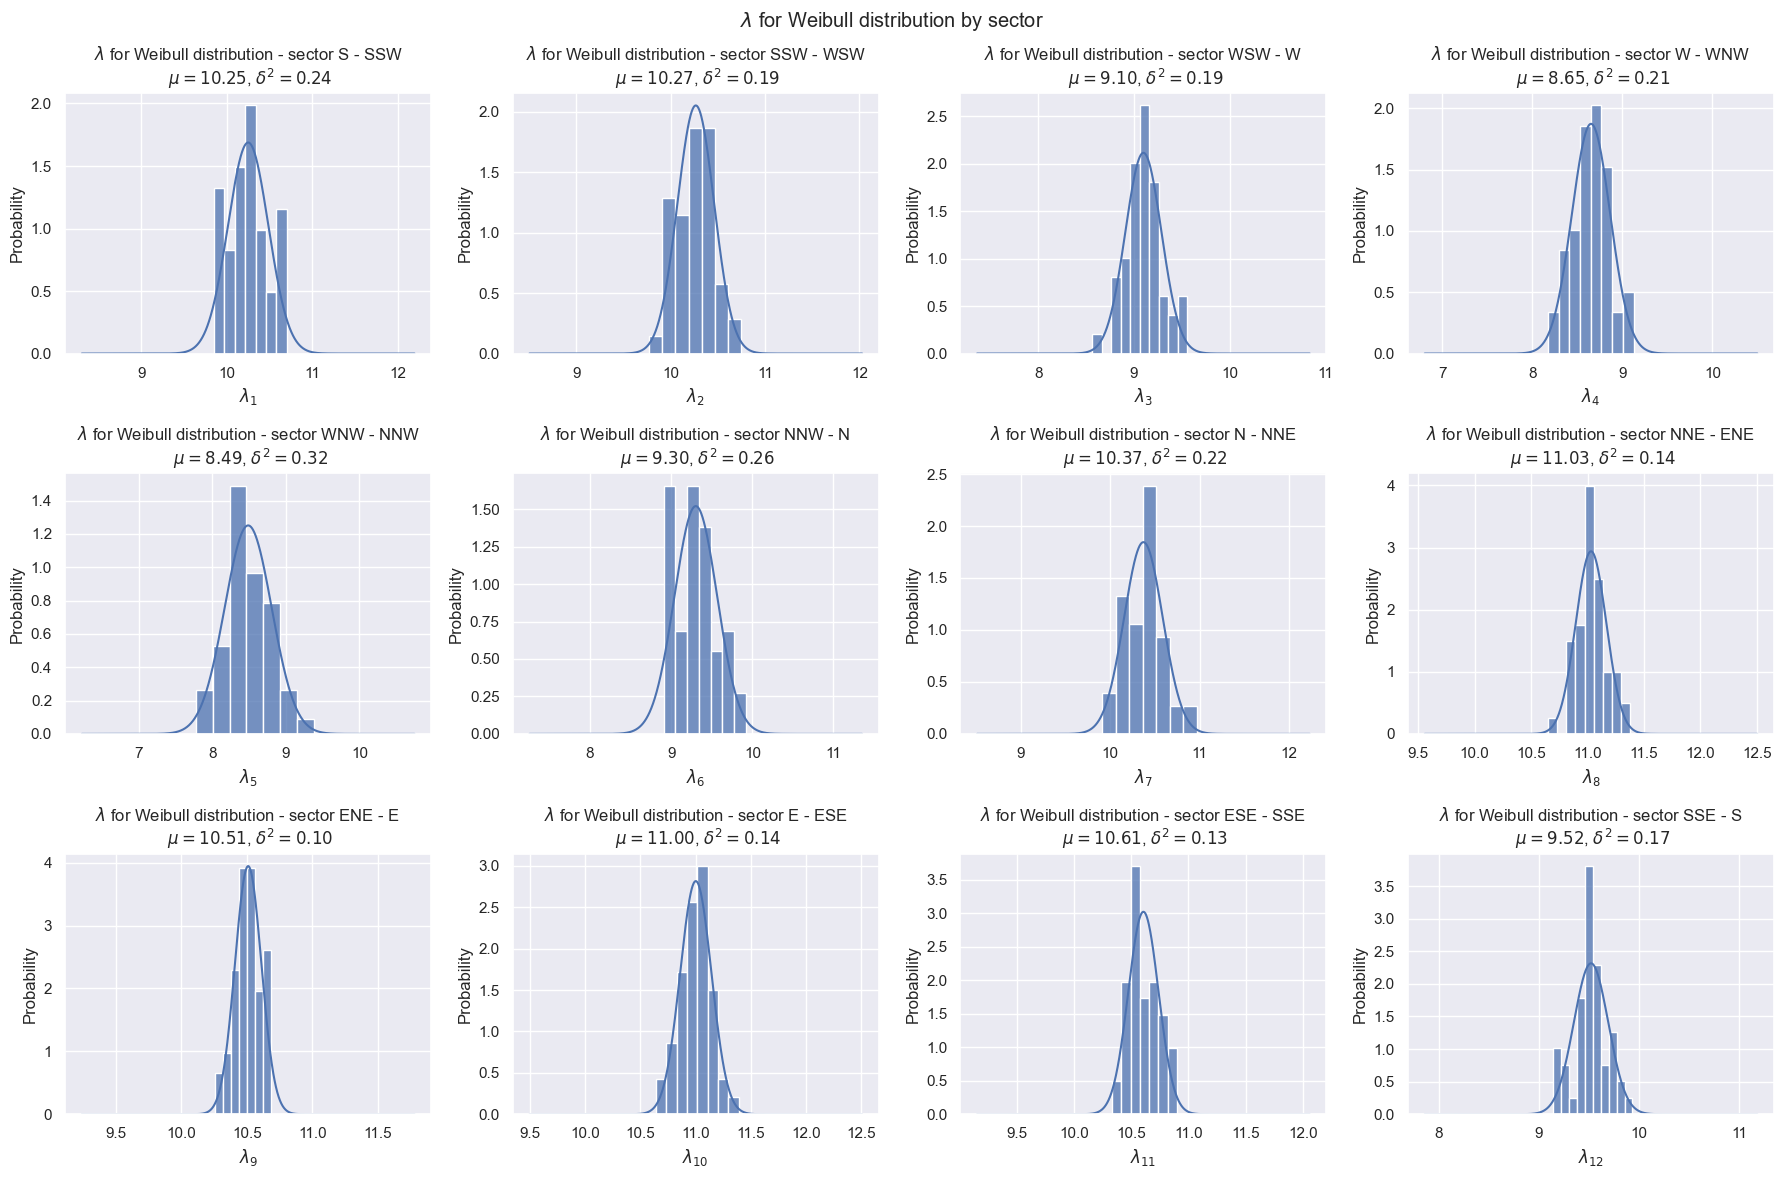

In [80]:
wb_lambda_distros = []
fig, axs = plt.subplots(3, 4, figsize=(18, 12))

for (ax, sector) in zip(axs.reshape(-1), sorted(wind_df.sector.unique())):
    sns.histplot(wb_lambda[:, int(sector)], ax=ax, stat="density")

    mean, var = norm.fit(wb_lambda[:, int(sector)])
    wb_lambda_distros.append(norm(loc=mean, scale=var))
    x_plot = np.linspace(mean - 4 * np.sqrt(var), mean + 4 * np.sqrt(var), 1000)
    sns.lineplot(x=x_plot, y=norm.pdf(x_plot, loc=mean, scale=var), ax=ax)

    ax.set_title(f'$\\lambda$ for Weibull distribution - sector {sector_labels[sector]} \n $\\mu={mean:.2f}$, $\\delta^2 = {var:.2f}$')
    ax.set_xlabel(f'$\\lambda_{{{int(sector) + 1}}}$')
    ax.set_ylabel('Probability')

fig.suptitle(rf'$\lambda$ for Weibull distribution by sector')
fig.tight_layout()
plt.show()

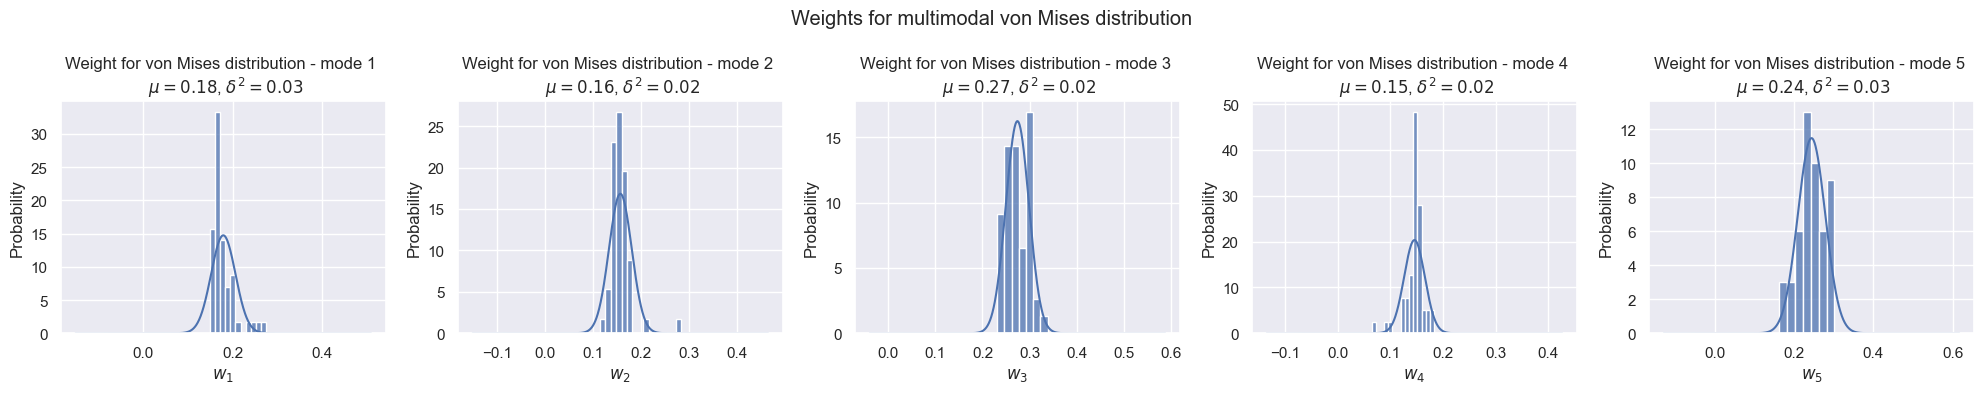

In [20]:
vm_weights_distros = []
fig, axs = plt.subplots(1, 5, figsize=(20, 4))

for i, ax in enumerate(axs):
    sns.histplot(vm_weights[:, i], ax=ax, stat="density")

    mean, var = norm.fit(vm_weights[:, i])
    vm_weights_distros.append(norm(loc=mean, scale=var))
    x_plot = np.linspace(mean - 2 * np.sqrt(var), mean + 2 * np.sqrt(var), 1000)
    sns.lineplot(x=x_plot, y=norm.pdf(x_plot, loc=mean, scale=var), ax=ax)

    ax.set_title(f'Weight for von Mises distribution - mode {i + 1} \n $\\mu={mean:.2f}$, $\\delta^2 = {var:.2f}$')
    ax.set_xlabel(f'$w_{{{i + 1}}}$')
    ax.set_ylabel('Probability')

fig.suptitle(rf'Weights for multimodal von Mises distribution')
fig.tight_layout()
plt.show()

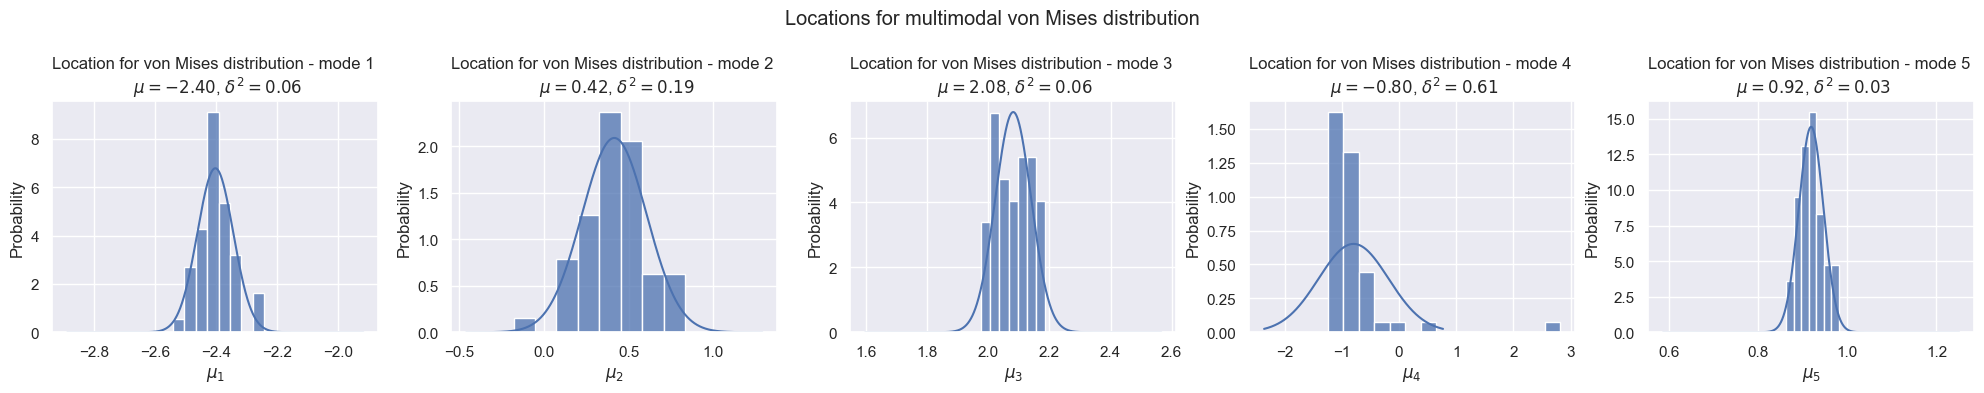

In [21]:
vm_mus_distros = []
fig, axs = plt.subplots(1, 5, figsize=(20, 4))

for i, ax in enumerate(axs):
    sns.histplot(vm_mus[:, i], ax=ax, stat="density")

    mean, var = norm.fit(vm_mus[:, i])
    vm_mus_distros.append(norm(loc=mean, scale=var))
    x_plot = np.linspace(mean - 2 * np.sqrt(var), mean + 2 * np.sqrt(var), 1000)
    sns.lineplot(x=x_plot, y=norm.pdf(x_plot, loc=mean, scale=var), ax=ax)

    ax.set_title(f'Location for von Mises distribution - mode {i + 1} \n $\\mu={mean:.2f}$, $\\delta^2 = {var:.2f}$')
    ax.set_xlabel(f'$\\mu_{{{i + 1}}}$')
    ax.set_ylabel('Probability')

fig.suptitle(rf'Locations for multimodal von Mises distribution')
fig.tight_layout()
plt.show()

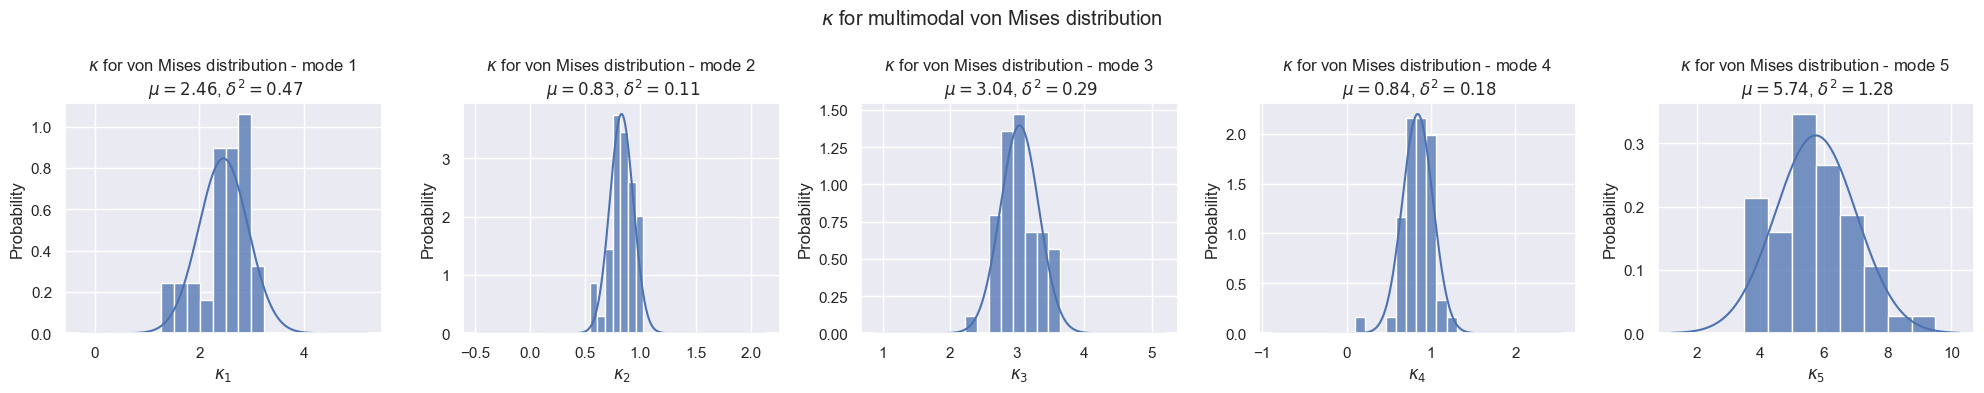

In [113]:
vm_lambdas_distros = []
fig, axs = plt.subplots(1, 5, figsize=(20, 4))

for i, ax in enumerate(axs):
    sns.histplot(vm_kappas[:, i], ax=ax, stat="density")

    mean, var = norm.fit(vm_kappas[:, i])
    vm_lambdas_distros.append(norm(loc=mean, scale=var))
    x_plot = np.linspace(mean - 4 * np.sqrt(var), mean + 4 * np.sqrt(var), 1000)
    sns.lineplot(x=x_plot, y=norm.pdf(x_plot, loc=mean, scale=var), ax=ax)

    ax.set_title(f'$\\kappa$ for von Mises distribution - mode {i + 1} \n $\\mu={mean:.2f}$, $\\delta^2 = {var:.2f}$')
    ax.set_xlabel(f'$\\kappa_{{{i + 1}}}$')
    ax.set_ylabel('Probability')

fig.suptitle(rf'$\kappa$ for multimodal von Mises distribution')
fig.tight_layout()
plt.show()

In the following code block, we define a function to generate synthetic wind data using the parameter distributions presented above. The synthetic data will be used in the next section, where we are analyzing how uncertainties in the wind resource affect the AEP of wind farms placed in the prevailing wind direction.

In [23]:
# Function to generate synthetic wind data based on the parameter distributions
def generate_wind_resource(timeframe : int = 24 * 365):
    # Sample parameter values from their distributions
    sampled_vm_weights = [dist.rvs() for dist in vm_weights_distros]
    sampled_vm_mus = [dist.rvs() for dist in vm_mus_distros]
    sampled_vm_lambdas = [dist.rvs() for dist in vm_lambdas_distros]

    sampled_wb_kappas = [dist.rvs() for dist in wb_kappa_distros]
    sampled_wb_lambdas = [dist.rvs() for dist in wb_lambda_distros]

    # Define the new multimodal von Mises distribution (for wind direction) and Weibull distributions (for wind speed on each sector)
    vm_modes = [vonmises(loc=_mu, kappa=_lambda) for _mu, _lambda in zip(sampled_vm_mus, sampled_vm_lambdas)]
    wb_distributions = [weibull_min(c=_kappa, scale=_lambda, loc=0) for _kappa, _lambda in zip(sampled_wb_kappas, sampled_wb_lambdas)]

    # Generate synthetic data for wind direction
    directions = [vm_modes[i].rvs() for i in np.random.choice(len(sampled_vm_weights), size=timeframe, p=sampled_vm_weights/sum(sampled_vm_weights))]

    # Create dataframe to hold data
    df = pd.DataFrame(directions, columns=['wd'])

    # Assign sector to synth data
    df['sector'] = (df.wd + np.pi) // (np.pi / 6)

    # Generate synth data for wind speed according to its sector
    df['ws'] = df.apply(lambda r: wb_distributions[int(r.sector)].rvs(), axis=1)

    site = UniformWeibullSite(p_wd=df.sector.value_counts(normalize=True).sort_index().values, a=sampled_wb_lambdas, k=sampled_wb_kappas, ti=0.06)

    return df, site

***

## Analyzing uncertainties on wind resource in a tandem wind farm configuration

Based on the previous findings, we can measure how much the uncertainties on wind speed and direction can impact the energy generation in a wind farm. For this study, we consider two scenarios:

* One where only Vineyard Wind is operational; and
* One where Vineyard Wind and New England Wind II are operational.

The first scenario will let us understand how changes in wind behaviour affect the Annual Energy Production (AEP) of an existing wind farm. These results will allows us to define a margin of reasonable values within which the AEP is expected to oscillate.

The second scenario, we chose to include a wind farm that is spaced about 12 km from Vineyard Wind, but located in the prevailing wind direction. By analyzing the results for simulations in this scenario, we will be able to quantify how much the AEP is expected to drop in situations with tandem wind farms due to inter-farm wake.

In the following code block, we import additional packages to help us in this analysis and load the geospatial data regarding the wind farms.

In [24]:
import windIO
from shapely.geometry import Point, Polygon
from shapely.plotting import plot_polygon

from py_wake.literature.gaussian_models import Bastankhah_PorteAgel_2014
from py_wake.wind_turbines import WindTurbine
from py_wake.wind_turbines.power_ct_functions import PowerCtTabular

cluster_data = windIO.load_yaml('../../Data/vineyard_revolution_system.yaml')

Below, we gather the location of each of Vineyard Wind's wind turbine generators (WTG) from the geospatial data. Their specific locations will be used when calculating the total AEP for this farm. We also plot the farm layout and its leased area.

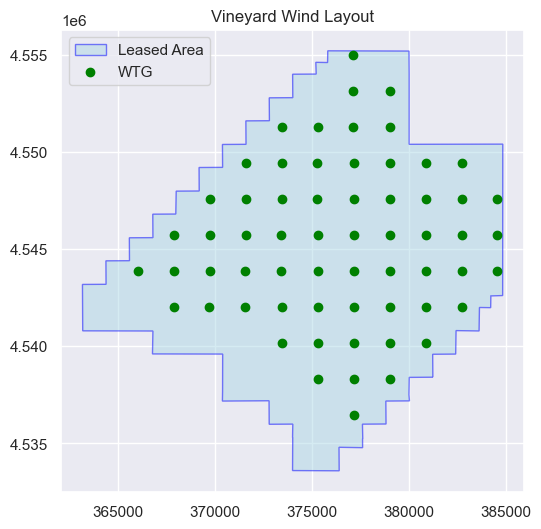

In [26]:
# Build polygon for Vineyard Wind leased area
vineyard_polygon = Polygon(zip(cluster_data["site"]["boundaries"]["polygons"][0]['x'], cluster_data["site"]["boundaries"]["polygons"][0]['y']))

# Get position of Vineyard Wind turbines
vy_x = cluster_data['wind_farm'][0]['layouts'][0]['coordinates']['x']
vy_y = cluster_data['wind_farm'][0]['layouts'][0]['coordinates']['y']

# Plot leased area and WTG locations
fig, ax = plt.subplots(figsize=(6, 6))

plot_polygon(vineyard_polygon, ax=ax, facecolor='lightblue', edgecolor='blue', alpha=0.5, add_points=False, label='Leased Area')
ax.scatter(vy_x, vy_y, color='green', marker='o', label='WTG')

ax.legend()
ax.set_aspect('equal')
ax.set_title('Vineyard Wind Layout')

plt.show()

Given that New England Wind II does not have a layout or number of WTGs defined by its developers yet, it was decided, for this study, to place them in a 1 x 1 nautical mile grid in a way that fills the entire leased area. Such a grid was chosen since it was also used in other US offshore wind projects in the same region (Revolution Wind, South Fork, Sunrise Wind, and Vineyard Wind itself).

At the end, 60 turbines were placed inside New England Wind II's leased area, and the final layout can be seen in the image below.

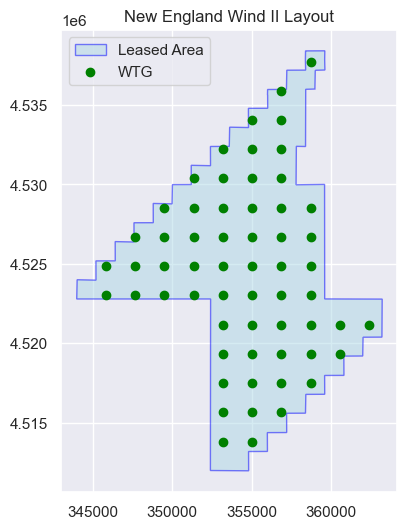

In [55]:
# Build polygon for New England Wind II leased area
ne_wind2_polygon = Polygon(zip(cluster_data["site"]["boundaries"]["polygons"][9]['x'], cluster_data["site"]["boundaries"]["polygons"][9]['y']))

# Place turbines in a 1 x 1 nautical mile grid inside the leased area
xmin, ymin, xmax, ymax = ne_wind2_polygon.bounds
xs = np.arange(xmin, xmax + 1840, 1840)
ys = np.arange(ymin, ymax + 1840, 1840)
pts = [(x, y) for x in xs for y in ys if ne_wind2_polygon.contains(Point(x, y))]
ne_x, ne_y = zip(*pts)
ne_x = np.array(ne_x)
ne_y = np.array(ne_y)

# Plot leased area and chosen WTG locations
fig, ax = plt.subplots(figsize=(6, 6))

plot_polygon(ne_wind2_polygon, ax=ax, facecolor='lightblue', edgecolor='blue', alpha=0.5, add_points=False, label='Leased Area')
ax.scatter(ne_x, ne_y, color='green', marker='o', label='WTG')

ax.legend()
ax.set_aspect('equal')
ax.set_title('Chosen New England Wind II Layout')

plt.show()

It was also considered that all wind turbines from New England Wind II would be of the same type as the ones installed in Vineyard Wind, and thus would have the same dimensions, and power and CT curves. In the following code block, we create an instance of the WTG (GE Haliade-X 13MW) to be used by pywake.

In [25]:
# Gather the WTG information
wtg_data = cluster_data['wind_farm'][0]['turbines']
ws = wtg_data["performance"]["power_curve"]['power_wind_speeds']
power = wtg_data["performance"]["power_curve"]['power_values']
ct = wtg_data["performance"]["Ct_curve"]["Ct_values"]

# Instantiate wind turbine inside pywake
wind_turbine = WindTurbine(
    name=wtg_data["name"],
    diameter=wtg_data["rotor_diameter"],
    hub_height=wtg_data["hub_height"],
    powerCtFunction=PowerCtTabular(
        ws=ws, power=power,
        power_unit="W", ct=ct,
    ),
)

We then calculated the total AEP produced by Vineyard Wind on these two scenarios for 1000 different wind conditions. These conditions were defined by acquiring samples from the distributions defined for each of the parameters described in the previous sections. By doing so, we were including the wind resource uncertainties into the calculation of the energy produced.

We chose to use Bastankhah/Porté-Agel model to simulate the wake deficit caused by the WTGs.

In [62]:
# Concatenate lists with WTG coordinates from Vineyard Wind and New England Wind II
all_x = np.r_[vy_x, ne_x]
all_y = np.r_[vy_y, ne_y]

# Create lists to store Vineyard Wind's AEP on both scenarios
aep_no_tandem = []
aep_tandem = []

for _ in range(100):
    # Generate wind resource site using parameters from the previous analysis
    synth_wind_data, site = generate_wind_resource()
    wfm = Bastankhah_PorteAgel_2014(site, wind_turbine, k=0.0324555)

    # Simulate the first scenario and store Vineyard Wind's AEP
    sim_res = wfm(vy_x, vy_y)
    aep_no_tandem.append(sim_res.aep().sum().item())

    # Simulate the second scenario (considering New England Wind II) and store Vineyard Wind's AEP
    sim_res = wfm(all_x, all_y)
    aep_tandem.append(sim_res.aep().isel(wt=np.arange(len(vy_x))).sum().item())

# Calculate the percentual difference in the AEP
aep_diff = [100 * (1 - aep_t/aep) for aep, aep_t in zip(aep_no_tandem, aep_tandem)]

The graphs below display the distribution of the AEP obtained for each scenario and the percentual difference.

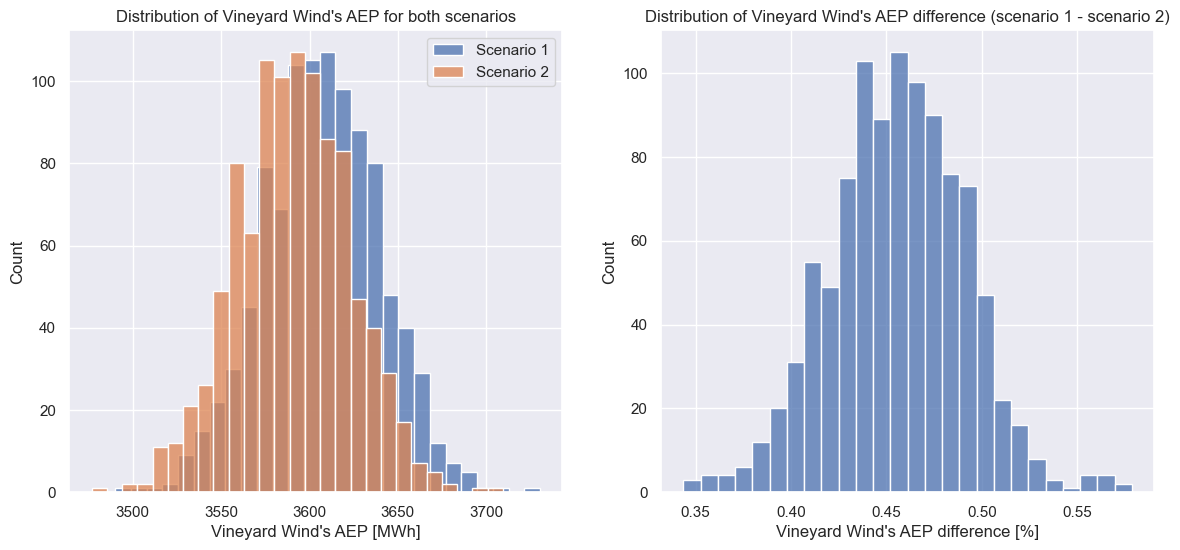

In [111]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(aep_no_tandem, label='Scenario 1', ax=ax1)
sns.histplot(aep_tandem, label='Scenario 2', ax=ax1)
ax1.set_xlabel('Vineyard Wind\'s AEP [MWh]')
ax1.set_title('Distribution of Vineyard Wind\'s AEP for both scenarios')
ax1.legend()

sns.histplot(aep_diff, ax=ax2)
ax2.set_xlabel('Vineyard Wind\'s AEP difference [%]')
ax2.set_title('Distribution of Vineyard Wind\'s AEP difference (scenario 1 - scenario 2)')

plt.show()

We can observe on the first graph that the majority of the cases for scenario 1 resulted in an AEP around 3.6 GWh, with some extreme cases were power generation was reduced or increased by 100 MWh. We can also observe that the AEP for scenario 2 follows a similar distribution but slightly shifted to the left. This shift was not a surprise, since Vineyard Wind's AEP was expected to suffer a reduction due to wake effects from New England Wind II.

The plot on the right depicts the distribution of Vineyard Wind's AEP percentual difference. These values were obtaining by subtracting, for the same sampled wind conditions, the AEPs from scenarios 1 and 2. From there, we can see that the expected value for AEP difference lies close to 0.45%, but this difference could vary $\pm$0.1% around this value.